## 1) Setup & Configuration

In [1]:
"""
This notebook configures and runs a fixed-aggregation individual identification experiment
using precomputed audio embeddings. It supports multiple datasets, two embedding backbones,
and two fixed aggregation strategies through a modular configuration block.

Main functionalities
- Sets a global random seed for reproducibility using Lightning.
- Defines dataset, embedding, and output paths relative to the project root.
- Supports two embedding backbones:
    1) BirdNET embeddings extracted from 3 s windows.
    2) Perch embeddings extracted from 5 s windows.
- Supports two fixed aggregation strategies at the vocalization level:
    1) onset: uses the first embedding of each vocalization.
    2) gap: applies global average pooling over all embeddings in the vocalization.
- Loads metadata and embedding parts required for training, validation, and testing.
- Configures logging, metrics, classification reports, and figure output directories.
- Specifies the core model hyperparameters for the downstream classifier.

Supported datasets
- chiffchaff: supports within-year and across-year splits.
- pipit: supports within-year and across-year splits.
- littleowl: supports across-year only.
- littlepenguin: supports within-year only and uses a single metadata CSV.
- kiwi: supports across-year only and uses a single metadata CSV.
- rtbc: supports across-year only and uses a single metadata CSV.

Key configuration variables
- SEED: Random seed used for reproducibility in splitting and training.
- DATASET_NAME: Dataset to use.
- SPLIT_TYPE: Evaluation subset to use. Options depend on the dataset.
- MODEL: Embedding backbone, either "birdnet" or "perch".
- AGGREGATION: Fixed aggregation strategy, either "onset" or "gap".
- EXPERIMENT_TAG: Descriptive tag used to name the current experiment.
- PARENT_DIR: Project root directory used to build all relative paths.

Notes
- In onset mode, only the first embedding of each vocalization is used.
- In gap mode, the embeddings of each vocalization are averaged before classification.
- Ensure that all input directories and metadata files exist before running the notebook.
"""

from lightning import seed_everything

SEED = 321
seed_everything(SEED, workers=True)

from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ---- Dataset / experiment config ----
DATASET_NAME = "greatTit"
SPLIT_TYPE = "acrossyear"          # only "acrossyear" is supported
MODEL = "perch"              # options: "birdnet", "perch"
AGGREGATION = "gap"          # options: "onset", "gap"
SPLIT_MODE = "random_seeded"      # options: "fixed_original", "random_seeded"


MODEL = MODEL.lower()
AGGREGATION = AGGREGATION.lower()

if MODEL not in {"birdnet", "perch"}:
    raise ValueError(f"Unknown MODEL: {MODEL}. Use 'birdnet' or 'perch'.")

if AGGREGATION not in {"onset", "gap"}:
    raise ValueError(f"Unknown AGGREGATION: {AGGREGATION}. Use 'onset' or 'gap'.")

EXPERIMENT_TAG = f"{MODEL}_{AGGREGATION}"
PARENT_DIR = Path.cwd().parent

# ---- Dataset-specific configuration ----
DATASET_CONFIG = {
    "greatTit": {
        "metadata_dir": "GreatTit_metadata",
        "label_key_col": "filename",
        "allowed_splits": {"acrossyear"},
        "train_files": {
            "acrossyear": "train_metadata.csv",
        },
        "val_files": {
            "acrossyear": "val_metadata.csv",
        },
        "test_files": {
            "acrossyear": "test_metadata.csv",
        },
    },
}

if DATASET_NAME not in DATASET_CONFIG:
    raise ValueError(
        f"Unknown DATASET_NAME: {DATASET_NAME}. "
        f"Choose from {list(DATASET_CONFIG.keys())}."
    )

cfg = DATASET_CONFIG[DATASET_NAME]

if SPLIT_TYPE not in cfg["allowed_splits"]:
    raise ValueError(
        f"Dataset '{DATASET_NAME}' does not support split '{SPLIT_TYPE}'. "
        f"Allowed splits: {sorted(cfg['allowed_splits'])}"
    )

# ---- Model-specific configuration ----
MODEL_CONFIG = {
    "birdnet": {
        "embeddings_dir": "Embeddings_from_3sPadding",
        "embedding_dim": 1024,
    },
    "perch": {
        "embeddings_dir": "Embeddings_from_5sPadding",
        "embedding_dim": 1280,
    },
}

model_cfg = MODEL_CONFIG[MODEL]

# ---- Input paths ----
PARTS_DIR = (
    PARENT_DIR
    / "Output_files"
    / model_cfg["embeddings_dir"]
    / f"{DATASET_NAME}_parquet_parts"
)

METADATA_DIR = PARENT_DIR / "Output_metadata" / cfg["metadata_dir"]
TRN_CSV = METADATA_DIR / cfg["train_files"][SPLIT_TYPE]

test_file = cfg["test_files"][SPLIT_TYPE]
TST_CSV = None if test_file is None else METADATA_DIR / test_file

val_file = cfg["val_files"][SPLIT_TYPE]
VAL_CSV = None if val_file is None else METADATA_DIR / val_file

# ---- Data columns ----
LABEL_KEY_COL = cfg["label_key_col"]
EMB_KEY_COL = "file_name"

# Optional quick subset of parts (0 = use all)
LIMIT_N_PARTS = 0

# ---- Output paths ----
LOG_ROOT = PARENT_DIR / "logs"
RUN_NAME = f"{DATASET_NAME}_{SPLIT_TYPE}_{EXPERIMENT_TAG}"
LOG_DIR = LOG_ROOT / DATASET_NAME / SPLIT_TYPE
LOG_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_DIR = PARENT_DIR / "Results" / DATASET_NAME / SPLIT_TYPE
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

METRICS_DIR = RESULTS_DIR / "Metrics"
METRICS_DIR.mkdir(parents=True, exist_ok=True)

METRICS_FILE = METRICS_DIR / f"{RUN_NAME}_final_metrics.csv"
CLASS_REPORT_TXT_FILE = METRICS_DIR / f"{RUN_NAME}_test_classification_report.txt"
CLASS_REPORT_CSV_FILE = METRICS_DIR / f"{RUN_NAME}_test_classification_report.csv"

AGGREGATE_METRICS_FILE = METRICS_DIR / f"{RUN_NAME}_aggregate_summary.csv"
AGGREGATE_PRETTY_FILE = METRICS_DIR / f"{RUN_NAME}_aggregate_summary_pretty.csv"

FIGURES_DIR = RESULTS_DIR / f"{RUN_NAME}_figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ---- Model hyperparameters ----
EMBEDDING_DIM = model_cfg["embedding_dim"]
HIDDEN_DIM = 256
LEARNING_RATE = 1e-3

print("DATASET_NAME:", DATASET_NAME)
print("SPLIT_TYPE:", SPLIT_TYPE)
print("MODEL:", MODEL)
print("SPLIT_MODE:", SPLIT_MODE)
print("AGGREGATION:", AGGREGATION)
print("PARTS_DIR:", PARTS_DIR)
print("TRN_CSV:", TRN_CSV)
print("VAL_CSV:", VAL_CSV)
print("TST_CSV:", TST_CSV)
print("LOG_DIR:", LOG_DIR / RUN_NAME)
print("METRICS_FILE:", METRICS_FILE)
print("FIGURES_DIR:", FIGURES_DIR)
print("EMBEDDING_DIM:", EMBEDDING_DIM)

Seed set to 321


DATASET_NAME: greatTit
SPLIT_TYPE: acrossyear
MODEL: perch
SPLIT_MODE: random_seeded
AGGREGATION: gap
PARTS_DIR: /teamspace/studios/this_studio/Output_files/Embeddings_from_5sPadding/greatTit_parquet_parts
TRN_CSV: /teamspace/studios/this_studio/Output_metadata/GreatTit_metadata/train_metadata.csv
VAL_CSV: /teamspace/studios/this_studio/Output_metadata/GreatTit_metadata/val_metadata.csv
TST_CSV: /teamspace/studios/this_studio/Output_metadata/GreatTit_metadata/test_metadata.csv
LOG_DIR: /teamspace/studios/this_studio/logs/greatTit/acrossyear/greatTit_acrossyear_perch_gap
METRICS_FILE: /teamspace/studios/this_studio/Results/greatTit/acrossyear/Metrics/greatTit_acrossyear_perch_gap_final_metrics.csv
FIGURES_DIR: /teamspace/studios/this_studio/Results/greatTit/acrossyear/greatTit_acrossyear_perch_gap_figures
EMBEDDING_DIM: 1280


## 2) Load and combine labels (one-hot → single label per file)

In [2]:
from pathlib import Path
import pandas as pd

def _load_with_split(path: Path, split_name: str) -> pd.DataFrame:
    df = pd.read_csv(path, dtype=str, keep_default_na=False)

    if LABEL_KEY_COL not in df.columns:
        raise ValueError(f"Missing filename column '{LABEL_KEY_COL}' in {path}.")

    # Normalize filename key for matching against embedding parquet rows
    df[LABEL_KEY_COL] = df[LABEL_KEY_COL].astype(str).str.strip().str.lower()

    # Keep the original split assignment from the metadata files
    df["source_split"] = split_name
    return df


csv_chunks = []

if "TRN_CSV" in locals() and TRN_CSV is not None and Path(TRN_CSV).exists():
    csv_chunks.append(_load_with_split(Path(TRN_CSV), "train"))

if "VAL_CSV" in locals() and VAL_CSV is not None and Path(VAL_CSV).exists():
    csv_chunks.append(_load_with_split(Path(VAL_CSV), "val"))

if "TST_CSV" in locals() and TST_CSV is not None and Path(TST_CSV).exists():
    csv_chunks.append(_load_with_split(Path(TST_CSV), "test"))

if not csv_chunks:
    raise ValueError(
        "No metadata CSVs found. Provide at least TRN_CSV "
        "(and optionally VAL_CSV/TST_CSV)."
    )

combined_df = pd.concat(csv_chunks, ignore_index=True)

# ------------------------------------------------------------------
# Build a unified label column
# ------------------------------------------------------------------
SINGLE_LABEL_COLS = [
    c for c in ["father", "class", "label", "individual_id"]
    if c in combined_df.columns
]

if SINGLE_LABEL_COLS:
    LABEL_VALUE_COL = SINGLE_LABEL_COLS[0]
    combined_df["label"] = combined_df[LABEL_VALUE_COL].astype(str).str.strip()
    print(f"[Single-label schema] Using '{LABEL_VALUE_COL}' as labels.")
else:
    non_label_cols = {LABEL_KEY_COL, "source_split"}
    indiv_cols = [c for c in combined_df.columns if c not in non_label_cols]

    if not indiv_cols:
        raise ValueError("No one-hot individual columns found in the metadata CSVs.")

    one_hot_block = combined_df[indiv_cols].astype(float)
    row_sums = one_hot_block.sum(axis=1)

    if (row_sums == 0).all():
        raise ValueError(
            "All rows in the one-hot block are zeros; no labeled files detected."
        )

    combined_df["label"] = one_hot_block.idxmax(axis=1)
    print(f"[One-hot schema] Derived labels from one-hot columns (n={len(indiv_cols)}).")

# ------------------------------------------------------------------
# Build filename -> label mapping
# ------------------------------------------------------------------
label_conflicts = (
    combined_df[[LABEL_KEY_COL, "label"]]
    .drop_duplicates()
    .groupby(LABEL_KEY_COL)["label"]
    .nunique()
)

conflicting_labels = label_conflicts[label_conflicts > 1]
if not conflicting_labels.empty:
    raise ValueError(
        f"Found {len(conflicting_labels)} filenames with conflicting labels across metadata files."
    )

combined_labels_dict = (
    combined_df[[LABEL_KEY_COL, "label"]]
    .drop_duplicates(subset=[LABEL_KEY_COL])
    .set_index(LABEL_KEY_COL)["label"]
    .to_dict()
)

# ------------------------------------------------------------------
# Build filename -> original split mapping
# This is useful for SPLIT_MODE == 'fixed_original'
# ------------------------------------------------------------------
source_split_series = (
    combined_df.drop_duplicates([LABEL_KEY_COL, "source_split"])
    .groupby(LABEL_KEY_COL)["source_split"]
    .agg(list)
)

split_conflicts = {k: v for k, v in source_split_series.items() if len(v) > 1}
if split_conflicts:
    print(
        f"⚠️ {len(split_conflicts)} filenames appear in multiple original splits. "
        "Keeping the first occurrence by priority (train > val > test)."
    )

priority = {"train": 0, "val": 1, "test": 2}

def _pick_first_split(splits):
    return sorted(splits, key=lambda x: priority.get(x, 99))[0]

source_split_by_file = {
    k: _pick_first_split(v) for k, v in source_split_series.items()
}

label_keys = set(combined_labels_dict.keys())

print(f"Loaded {len(combined_df):,} metadata rows.")
print(f"Unique labeled audio files: {len(label_keys):,}")
print(f"Original split mode available: {sorted(set(combined_df['source_split']))}")
print("Example label mapping:", list(combined_labels_dict.items())[:3])

if SPLIT_MODE == "fixed_original":
    print("SPLIT_MODE = fixed_original -> downstream code should use source_split_by_file.")
elif SPLIT_MODE == "random_seeded":
    print("SPLIT_MODE = random_seeded -> downstream code should ignore source_split_by_file and rebuild splits with SEED.")
else:
    raise ValueError(
        f"Unknown SPLIT_MODE: {SPLIT_MODE}. "
        "Use 'fixed_original' or 'random_seeded'."
    )

[Single-label schema] Using 'father' as labels.
Loaded 74,048 metadata rows.
Unique labeled audio files: 74,048
Original split mode available: ['test', 'train', 'val']
Example label mapping: [('20221o78_20220420_050000_41810944.wav', 'pf71344'), ('20221o78_20220420_040000_123724160.wav', 'pf71344'), ('20221o78_20220420_040000_127732608.wav', 'pf71344')]
SPLIT_MODE = random_seeded -> downstream code should ignore source_split_by_file and rebuild splits with SEED.


## 3) Read embeddings from Parquet parts and keep only labeled files

This loads one part at a time to keep memory usage reasonable.

In [3]:
# Find Parquet parts
parts = sorted(PARTS_DIR.glob("part_*.parquet"))
if LIMIT_N_PARTS > 0:
    parts = parts[:LIMIT_N_PARTS]

if not parts:
    raise FileNotFoundError(f"No parquet parts found in: {PARTS_DIR}")

print(f"Found {len(parts)} parquet parts; first 3: {[p.name for p in parts[:3]]}")

# ------------------------------------------------------------------
# Load labeled embedding rows and preserve original split information
# ------------------------------------------------------------------
kept_chunks = []
total_rows_read = 0
total_rows_kept = 0

for part in parts:
    df_part = pd.read_parquet(part)
    total_rows_read += len(df_part)

    if EMB_KEY_COL not in df_part.columns:
        raise ValueError(f"Parquet part {part.name} is missing column '{EMB_KEY_COL}'")

    # Normalize filename column for matching
    df_part[EMB_KEY_COL] = (
        df_part[EMB_KEY_COL]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    # Keep only rows whose file appears in the metadata
    df_part = df_part[df_part[EMB_KEY_COL].isin(label_keys)].copy()
    if df_part.empty:
        continue

    # Drop path if present
    if "path" in df_part.columns:
        df_part = df_part.drop(columns=["path"])

    # Attach file-level label and original split
    df_part["label"] = df_part[EMB_KEY_COL].map(combined_labels_dict)
    df_part["source_split"] = df_part[EMB_KEY_COL].map(source_split_by_file)

    # Safety checks
    if df_part["label"].isna().any():
        examples = df_part.loc[df_part["label"].isna(), EMB_KEY_COL].unique()[:5]
        raise ValueError(
            f"Missing labels for some embedding rows after mapping. Examples: {examples}"
        )

    if df_part["source_split"].isna().any():
        examples = df_part.loc[df_part["source_split"].isna(), EMB_KEY_COL].unique()[:5]
        raise ValueError(
            f"Missing source_split for some embedding rows after mapping. Examples: {examples}"
        )

    total_rows_kept += len(df_part)
    kept_chunks.append(df_part)

if not kept_chunks:
    raise ValueError(
        "No embedding rows matched the labeled filenames from the metadata CSVs."
    )

trainvaltest_df = pd.concat(kept_chunks, ignore_index=True)

print(f"Total parquet rows read: {total_rows_read:,}")
print(f"Rows before aggregation: {len(trainvaltest_df):,}")
print(f"Unique files before aggregation: {trainvaltest_df[EMB_KEY_COL].nunique():,}")


Found 25 parquet parts; first 3: ['part_0000.parquet', 'part_0001.parquet', 'part_0002.parquet']


Total parquet rows read: 76,498
Rows before aggregation: 76,498
Unique files before aggregation: 74,048



## 4) Apply file-level aggregation while preserving source_split


In [4]:

group_cols = [EMB_KEY_COL, "label", "source_split"]

if AGGREGATION == "onset":
    if "start_time" not in trainvaltest_df.columns:
        raise ValueError("The 'start_time' column is required for onset aggregation.")

    # Keep the first embedding per file after temporal sorting
    trainvaltest_df = (
        trainvaltest_df
        .sort_values(by=[EMB_KEY_COL, "start_time"])
        .groupby(group_cols, as_index=False)
        .first()
    )

    print("Applied onset aggregation: kept the first embedding per file.")

elif AGGREGATION == "gap":
    # Average numeric columns per file
    trainvaltest_df = (
        trainvaltest_df
        .groupby(group_cols, as_index=False)
        .mean(numeric_only=True)
    )

    # Drop time columns after pooling if they remain
    cols_to_drop = [c for c in ["start_time", "end_time"] if c in trainvaltest_df.columns]
    if cols_to_drop:
        trainvaltest_df = trainvaltest_df.drop(columns=cols_to_drop)

    print("Applied GAP aggregation: averaged embeddings per file.")

else:
    raise ValueError(
        f"Unknown AGGREGATION: {AGGREGATION}. Use 'onset' or 'gap'."
    )

# Keep split order consistent for inspection
split_order = pd.CategoricalDtype(categories=["train", "val", "test"], ordered=True)
trainvaltest_df["source_split"] = trainvaltest_df["source_split"].astype(split_order)

print(f"Rows after aggregation: {len(trainvaltest_df):,}")
print(f"Unique files after aggregation: {trainvaltest_df[EMB_KEY_COL].nunique():,}")
print("Rows per original split after aggregation:")
print(trainvaltest_df["source_split"].value_counts(dropna=False).sort_index())

print("Missing labels:", trainvaltest_df["label"].isna().sum())
print("Missing source_split:", trainvaltest_df["source_split"].isna().sum())
print("Final columns:", trainvaltest_df.columns.tolist())

assert trainvaltest_df[EMB_KEY_COL].nunique() == len(trainvaltest_df), (
    "Aggregation failed: more than one row remains for at least one file."
)

print("\nExample rows:")
display(
    trainvaltest_df[
        [EMB_KEY_COL, "label", "source_split"] +
        [c for c in ["start_time", "end_time"] if c in trainvaltest_df.columns]
    ].head()
)

Applied GAP aggregation: averaged embeddings per file.
Rows after aggregation: 74,048
Unique files after aggregation: 74,048
Rows per original split after aggregation:
source_split
train    59139
val       7396
test      7513
Name: count, dtype: int64
Missing labels: 0
Missing source_split: 0
Final columns: ['file_name', 'label', 'source_split', 'dim_0', 'dim_1', 'dim_2', 'dim_3', 'dim_4', 'dim_5', 'dim_6', 'dim_7', 'dim_8', 'dim_9', 'dim_10', 'dim_11', 'dim_12', 'dim_13', 'dim_14', 'dim_15', 'dim_16', 'dim_17', 'dim_18', 'dim_19', 'dim_20', 'dim_21', 'dim_22', 'dim_23', 'dim_24', 'dim_25', 'dim_26', 'dim_27', 'dim_28', 'dim_29', 'dim_30', 'dim_31', 'dim_32', 'dim_33', 'dim_34', 'dim_35', 'dim_36', 'dim_37', 'dim_38', 'dim_39', 'dim_40', 'dim_41', 'dim_42', 'dim_43', 'dim_44', 'dim_45', 'dim_46', 'dim_47', 'dim_48', 'dim_49', 'dim_50', 'dim_51', 'dim_52', 'dim_53', 'dim_54', 'dim_55', 'dim_56', 'dim_57', 'dim_58', 'dim_59', 'dim_60', 'dim_61', 'dim_62', 'dim_63', 'dim_64', 'dim_65', 'd

,file_name,label,source_split
0,20201b161_20200418_040000_130451999.wav,te80930,val
1,20201b161_20200418_050000_11502511.wav,te80930,train
2,20201b161_20200418_050000_13585746.wav,te80930,train
3,20201b161_20200418_050000_13982440.wav,te80930,test
4,20201b161_20200418_050000_20011659.wav,te80930,train


## 5) Stratified split by file (train/val/test)

Split 60/20/20 (random) or 80/10/10 (original)

In [5]:
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------------
# Build train_df / val_df / test_df according to SPLIT_MODE
# ------------------------------------------------------------------
if SPLIT_MODE == "fixed_original":
    train_df = trainvaltest_df[trainvaltest_df["source_split"] == "train"].copy()
    val_df   = trainvaltest_df[trainvaltest_df["source_split"] == "val"].copy()
    test_df  = trainvaltest_df[trainvaltest_df["source_split"] == "test"].copy()

    split_description = "Using original metadata split (source_split)."

elif SPLIT_MODE == "random_seeded":
    # Rebuild splits at the file level, independently within each individual
    file_df = (
        trainvaltest_df[[EMB_KEY_COL, "label"]]
        .drop_duplicates(subset=[EMB_KEY_COL])
        .reset_index(drop=True)
    )

    train_files = []
    val_files = []
    test_files = []

    for indiv, group in file_df.groupby("label", sort=True):
        files = group[EMB_KEY_COL].tolist()

        if len(files) < 3:
            raise ValueError(
                f"Individual '{indiv}' has only {len(files)} files. "
                "At least 3 are needed to build train/val/test splits."
            )

        # 60% train, 40% temporary
        indiv_train, indiv_temp = train_test_split(
            files,
            test_size=0.40,
            random_state=SEED,
            shuffle=True,
        )

        if len(indiv_temp) < 2:
            raise ValueError(
                f"Individual '{indiv}' produced only {len(indiv_temp)} temporary files "
                "after the first split. Cannot divide them into val/test."
            )

        # Split temporary set into 20% val and 20% test
        indiv_val, indiv_test = train_test_split(
            indiv_temp,
            test_size=0.50,
            random_state=SEED,
            shuffle=True,
        )

        train_files.extend(indiv_train)
        val_files.extend(indiv_val)
        test_files.extend(indiv_test)

    train_files = set(train_files)
    val_files = set(val_files)
    test_files = set(test_files)

    train_df = trainvaltest_df[trainvaltest_df[EMB_KEY_COL].isin(train_files)].copy()
    val_df   = trainvaltest_df[trainvaltest_df[EMB_KEY_COL].isin(val_files)].copy()
    test_df  = trainvaltest_df[trainvaltest_df[EMB_KEY_COL].isin(test_files)].copy()

    split_description = (
        "Using random_seeded split at the file level, applied independently within each individual "
        f"(SEED={SEED}, approx. 60/20/20 per individual)."
    )

else:
    raise ValueError(
        f"Unknown SPLIT_MODE: {SPLIT_MODE}. "
        "Use 'fixed_original' or 'random_seeded'."
    )

# ------------------------------------------------------------------
# Clean indices
# ------------------------------------------------------------------
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

# ------------------------------------------------------------------
# Sanity checks and summary
# ------------------------------------------------------------------
print(split_description)
print(f"Train: {len(train_df):,} rows")
print(f"Validation: {len(val_df):,} rows")
print(f"Test: {len(test_df):,} rows")

print(f"Train files: {train_df[EMB_KEY_COL].nunique():,}")
print(f"Validation files: {val_df[EMB_KEY_COL].nunique():,}")
print(f"Test files: {test_df[EMB_KEY_COL].nunique():,}")

print(f"Labels in TRN: {len(train_df['label'].dropna().unique())}")
print(f"Labels in VAL: {len(val_df['label'].dropna().unique())}")
print(f"Labels in TST: {len(test_df['label'].dropna().unique())}")

train_file_set = set(train_df[EMB_KEY_COL].unique())
val_file_set   = set(val_df[EMB_KEY_COL].unique())
test_file_set  = set(test_df[EMB_KEY_COL].unique())

assert train_file_set.isdisjoint(val_file_set), "Train/Val file overlap detected."
assert train_file_set.isdisjoint(test_file_set), "Train/Test file overlap detected."
assert val_file_set.isdisjoint(test_file_set), "Val/Test file overlap detected."

print("No file overlap detected across train/val/test splits.")

Using random_seeded split at the file level, applied independently within each individual (SEED=321, approx. 60/20/20 per individual).
Train: 44,328 rows
Validation: 14,811 rows
Test: 14,909 rows
Train files: 44,328
Validation files: 14,811
Test files: 14,909
Labels in TRN: 242
Labels in VAL: 242
Labels in TST: 242
No file overlap detected across train/val/test splits.


## 6) Label encoder

In [6]:
le = LabelEncoder()

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

le.fit(train_df["label"])

train_labels = set(le.classes_)
val_labels = set(val_df["label"].dropna().unique())
test_labels = set(test_df["label"].dropna().unique())

missing_in_train_val = val_labels - train_labels
missing_in_train_test = test_labels - train_labels

if missing_in_train_val:
    raise ValueError(
        f"Validation contains labels unseen in training: {sorted(missing_in_train_val)}"
    )

if missing_in_train_test:
    raise ValueError(
        f"Test contains labels unseen in training: {sorted(missing_in_train_test)}"
    )

train_df["label"] = le.transform(train_df["label"])
val_df["label"] = le.transform(val_df["label"])
test_df["label"] = le.transform(test_df["label"])

print(f"Number of classes: {len(le.classes_)}")
print("First 10 encoded classes:", list(le.classes_[:10]))

Number of classes: 242
First 10 encoded classes: ['pf71344', 'pf71356', 'pf71360', 'pf71373', 'pf71378', 'pf71395', 'pf71411', 'pf71419', 'pf71436', 'pf71904']


## 7)Prepare Datasets for PyTorch

In [7]:
from torch.utils.data import Dataset
import torch

def build_pooled_per_file_dicts(df, key_col, dims_cols, label_col):
    """
    Return (embeddings_dict, id_dict, file_list) from a pooled DataFrame.

    Assumes the input DataFrame already contains exactly one aggregated embedding
    vector per file, as produced by onset or GAP aggregation.
    """
    embeddings_dict = {}
    id_dict = {}

    for _, row in df.iterrows():
        file_name = row[key_col]
        vector = row[dims_cols].to_numpy(dtype="float32")  # shape (D,)

        embeddings_dict[file_name] = vector
        id_dict[file_name] = row[label_col]

    files = list(id_dict.keys())
    return embeddings_dict, id_dict, files


# Identify embedding dimension columns
dims_cols = [c for c in train_df.columns if c.startswith("dim_")]

# Train
audio_train_embeddings, id_train_dict, train_files = build_pooled_per_file_dicts(
    train_df, EMB_KEY_COL, dims_cols, "label"
)

# Val
audio_val_embeddings, id_val_dict, val_files = build_pooled_per_file_dicts(
    val_df, EMB_KEY_COL, dims_cols, "label"
)

# Test
audio_test_embeddings, id_test_dict, test_files = build_pooled_per_file_dicts(
    test_df, EMB_KEY_COL, dims_cols, "label"
)


class SubsetAudioDataset(Dataset):
    """
    Return (embedding, label) for a subset of files.

    Parameters
    ----------
    file_list : list
        List of file names belonging to the split.
    audio_embeddings : dict
        Dictionary mapping file_name -> pooled embedding vector of shape (D,).
    file_to_label : dict
        Dictionary mapping file_name -> encoded class label.
    """
    def __init__(self, file_list, audio_embeddings, file_to_label):
        self.file_list = file_list
        self.audio_embeddings = audio_embeddings
        self.file_to_label = file_to_label

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file_name = self.file_list[idx]
        emb_np = self.audio_embeddings[file_name]  # shape (D,)

        if emb_np.ndim != 1:
            raise ValueError(
                f"Expected a 1D pooled embedding for file '{file_name}', "
                f"but got shape {emb_np.shape}"
            )

        embeddings = torch.tensor(emb_np, dtype=torch.float32)  # shape (D,)
        label = torch.tensor(self.file_to_label[file_name], dtype=torch.long)

        return embeddings, label


# Create datasets
train_dataset = SubsetAudioDataset(train_files, audio_train_embeddings, id_train_dict)
val_dataset   = SubsetAudioDataset(val_files,   audio_val_embeddings,  id_val_dict)
test_dataset  = SubsetAudioDataset(test_files,  audio_test_embeddings, id_test_dict)

print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

Train size: 44328
Validation size: 14811
Test size: 14909


## 8) Counting Individual Frequencies per Dataset Split

,train,val,test
216,1433,478,478
61,1418,473,473
128,820,273,274
199,674,225,225
196,655,218,219
...,...,...,...
66,9,3,3
31,9,3,3
175,9,3,4
209,9,3,3


=== Dataset metrics (all splits combined) ===
Total vocalizations: 74048
Maximum vocalizations per individual: 2389
Minimum vocalizations per individual: 15
Vocalizations per individual (mean ± SD): 306.0 ± 313.9
Vocalizations per individual (mean ± SD, rounded): 306 ± 314


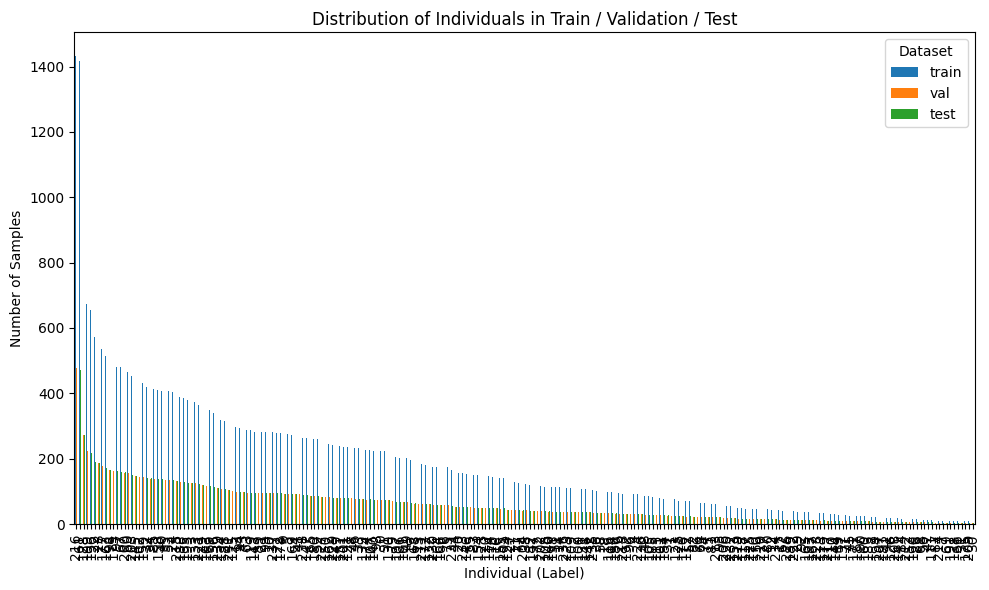

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

# --- Count labels in each split ---
def count_labels(dataset):
    """Count label frequencies in a PyTorch dataset."""
    return Counter(label.item() for _, label in dataset)

datasets = {
    "train": train_dataset,
    "val": val_dataset,
    "test": test_dataset
}

# Create DataFrame with counts
counts_df = pd.DataFrame({
    split: pd.Series(count_labels(ds))
    for split, ds in datasets.items()
}).fillna(0).astype(int)

# --- Sort by frequency in train ---
counts_df = counts_df.sort_values(by="train", ascending=False)

# --- Compute totals (not for plotting) ---
total_per_individual = counts_df.sum(axis=1)

# --- Metrics ---
total_vocalizations = int(total_per_individual.sum())
max_vocalizations   = int(total_per_individual.max())
min_vocalizations   = int(total_per_individual.min())
mean_vocalizations  = float(total_per_individual.mean())
std_vocalizations   = float(total_per_individual.std(ddof=1))  # sample SD

# --- Display counts DataFrame ---
display(counts_df)

# --- Print requested metrics ---
print("=== Dataset metrics (all splits combined) ===")
print(f"Total vocalizations: {total_vocalizations}")
print(f"Maximum vocalizations per individual: {max_vocalizations}")
print(f"Minimum vocalizations per individual: {min_vocalizations}")
print(f"Vocalizations per individual (mean ± SD): {mean_vocalizations:.1f} ± {std_vocalizations:.1f}")
print(f"Vocalizations per individual (mean ± SD, rounded): {round(mean_vocalizations):.0f} ± {round(std_vocalizations):.0f}")

# --- Plot per-split distribution ---
counts_df.plot(kind='bar', figsize=(10, 6))
plt.xlabel('Individual (Label)')
plt.ylabel('Number of Samples')
plt.title('Distribution of Individuals in Train / Validation / Test')
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()


## 9) Lightning DataModule with Custom Collate (variable-length sequences)

In [9]:
from lightning import LightningDataModule
from torch.utils.data import DataLoader
import torch


class PooledEmbeddingDataModule(LightningDataModule):
    def __init__(
        self,
        train_dataset,
        val_dataset,
        test_dataset,
        batch_size: int = 32,
        num_workers: int = 0,              # 0 is safest in notebooks
        pin_memory: bool = False,          # set True if training on GPU
        persistent_workers: bool = False,  # True only if num_workers > 0
        drop_last: bool = False,
    ):
        super().__init__()
        self.train_dataset = train_dataset
        self.val_dataset = val_dataset
        self.test_dataset = test_dataset

        self.batch_size = batch_size
        self.num_workers = num_workers
        self.pin_memory = pin_memory
        self.persistent_workers = persistent_workers if num_workers > 0 else False
        self.drop_last = drop_last

    def _make_loader(self, dataset, shuffle: bool):
        return DataLoader(
            dataset,
            batch_size=self.batch_size,
            shuffle=shuffle,
            num_workers=self.num_workers,
            pin_memory=self.pin_memory,
            persistent_workers=self.persistent_workers,
            drop_last=self.drop_last,
        )

    def train_dataloader(self):
        return self._make_loader(self.train_dataset, shuffle=True)

    def val_dataloader(self):
        return self._make_loader(self.val_dataset, shuffle=False)

    def test_dataloader(self):
        return self._make_loader(self.test_dataset, shuffle=False)


use_cuda = torch.cuda.is_available()

data_module = PooledEmbeddingDataModule(
    train_dataset,
    val_dataset,
    test_dataset,
    batch_size=32,
    num_workers=0,
    pin_memory=use_cuda,
    persistent_workers=False,
    drop_last=False,
)

## 10) Birdsong Classifier LightningModule FCNN

In [10]:
import torch
from torch import nn
import torch.nn.functional as F
from lightning import LightningModule
import torchmetrics
from torchmetrics.classification import F1Score
import logging

logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)


class BirdsongClassifier(LightningModule):
    """
    Fully connected classifier for fixed-size embedding vectors of shape (B, D).
    """

    def __init__(
        self,
        embedding_dim: int,
        hidden_dim: int,
        num_classes: int,
        lr: float = 1e-3,
        dropout: float = 0.0,
        class_weights: torch.Tensor | None = None,
    ):
        super().__init__()
        self.save_hyperparameters(ignore=["class_weights"])
        self.class_weights = class_weights

        self.net = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

        self.train_accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.val_accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.test_accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)

        self.val_f1 = torchmetrics.F1Score(
            task="multiclass",
            num_classes=num_classes,
            average="macro",
        )
        self.test_f1 = torchmetrics.F1Score(
            task="multiclass",
            num_classes=num_classes,
            average="macro",
        )

        self.criterion = nn.CrossEntropyLoss(weight=None)

    def setup(self, stage=None):
        if self.class_weights is not None:
            self.criterion = nn.CrossEntropyLoss(weight=self.class_weights.to(self.device))

    @staticmethod
    def _unpack_batch(batch):
        """
        Support both (x, y) and legacy (x, lengths, y) batches.
        Lengths are ignored for the FCN model.
        """
        if isinstance(batch, (list, tuple)):
            if len(batch) == 2:
                x, y = batch
                return x, y
            if len(batch) == 3:
                x, _, y = batch
                return x, y
        raise ValueError("Expected batch as (x, y) or (x, lengths, y)")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        logits = self.net(x)  # (B, C)
        return logits

    def _shared_step(self, batch, stage: str):
        x, y = self._unpack_batch(batch)
        logits = self(x)
        loss = self.criterion(logits, y)

        if stage == "train":
            acc = self.train_accuracy(logits, y)
            self.log("train_loss", loss, prog_bar=True)
            self.log("train_acc", acc, prog_bar=True)
            return loss

        if stage == "val":
            acc = self.val_accuracy(logits, y)
            f1 = self.val_f1(logits, y)
            self.log("val_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
            self.log("val_acc", acc, prog_bar=True, on_step=False, on_epoch=True)
            self.log("val_f1", f1, prog_bar=True, on_step=False, on_epoch=True)
            return loss

        if stage == "test":
            acc = self.test_accuracy(logits, y)
            f1 = self.test_f1(logits, y)
            self.log("test_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
            self.log("test_acc", acc, prog_bar=True, on_step=False, on_epoch=True)
            self.log("test_f1", f1, prog_bar=True, on_step=False, on_epoch=True)
            return loss

        raise ValueError(f"Unknown stage: {stage}")

    def training_step(self, batch, batch_idx):
        loss = self._shared_step(batch, stage="train")
        logger.info(f"Batch {batch_idx} - Train Loss: {loss.item():.4f}")
        return loss

    def validation_step(self, batch, batch_idx):
        self._shared_step(batch, stage="val")

    def test_step(self, batch, batch_idx):
        loss = self._shared_step(batch, stage="test")
        logger.info(f"Batch {batch_idx} - Test Loss: {loss.item():.4f}")

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

In [11]:
all_labels = (
    list(id_train_dict.values()) +
    list(id_val_dict.values()) +
    list(id_test_dict.values())
)

model = BirdsongClassifier(
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=len(set(all_labels)),  # Adjusted based on label encoder
    lr=LEARNING_RATE
)


## 11) Define Callbacks for Model Checkpointing and Early Stopping

In [12]:
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping

# Save the best model (by val_f1) and also keep the last checkpoint
checkpoint_callback = ModelCheckpoint(
    monitor="val_f1",
    mode="max",
    save_top_k=1,
    save_last=True,
    filename=f"best-{DATASET_NAME}-{SPLIT_TYPE}-{EXPERIMENT_TAG}-{{epoch:02d}}-{{val_f1:.4f}}"
    # auto_insert_metric_name=False,  # uncomment if you don't want Lightning to append metric names
)

# Early stopping if validation doesn't improve
early_stop_callback = EarlyStopping(
    monitor="val_f1",
    mode="max",
    patience=10,
    min_delta=1e-4,
)


## 12) Trainer configuration with TensorBoard and CSV loggers

In [13]:
from lightning import Trainer
from lightning.pytorch.loggers import TensorBoardLogger, CSVLogger

# TensorBoard + CSV under: logs/<DATASET_NAME>/<SPLIT_TYPE>/<RUN_NAME>/version_x/
tb_logger = TensorBoardLogger(
    save_dir=str(LOG_DIR),   # logs/<DATASET_NAME>/<SPLIT_TYPE>
    name=RUN_NAME,           # <DATASET_NAME>_<SPLIT_TYPE>_RNN
)

csv_logger = CSVLogger(
    save_dir=str(LOG_DIR),   # same root, same run name
    name=RUN_NAME,
)

trainer = Trainer(
    max_epochs=40,
    accelerator="auto",
    devices="auto",
    callbacks=[checkpoint_callback, early_stop_callback],
    logger=[tb_logger, csv_logger],
    log_every_n_steps=10,
    # Reproducibility and stability (safe defaults)
    deterministic=True,        # ensures repeatable results (may be slightly slower)
    # precision="16-mixed",    # optional: speed-up on GPU; leave commented to keep numerics identical
)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


## 13) Train the model

In [14]:
trainer.fit(model, datamodule=data_module)

2026-04-25 01:21:09.153781: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-25 01:21:09.473014: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777080069.641959  468501 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777080069.695683  468501 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-25 01:21:10.171874: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

## 14) Plot training and validation metrics from CSV logs

Reading metrics from: /teamspace/studios/this_studio/logs/greatTit/acrossyear/greatTit_acrossyear_perch_gap/version_9/metrics.csv


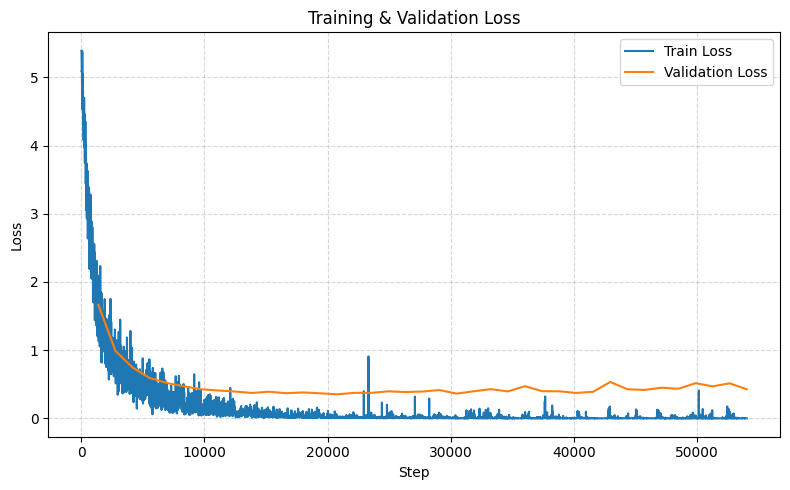

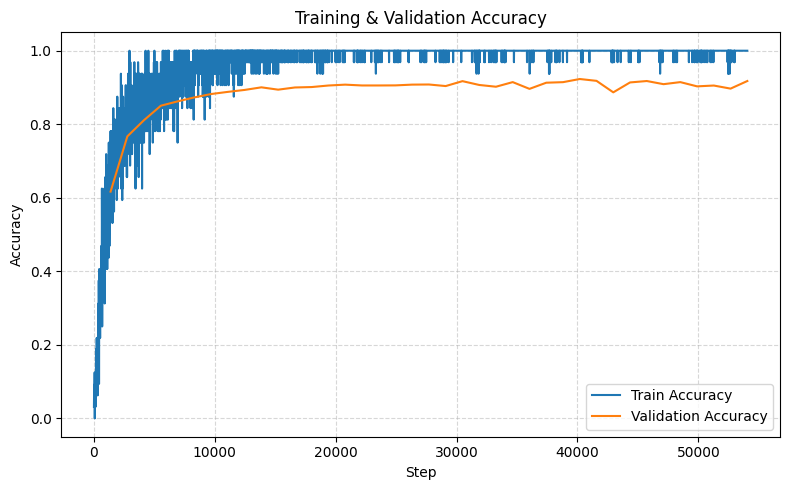

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Find the latest version directory created by the loggers
run_dir = LOG_DIR / RUN_NAME
version_dirs = sorted([p for p in run_dir.glob("version_*") if p.is_dir()],
                      key=lambda p: int(p.name.split("_")[-1]))
if not version_dirs:
    raise FileNotFoundError(f"No version_* folders found under {run_dir}")
latest = version_dirs[-1]
metrics_csv = latest / "metrics.csv"
print("Reading metrics from:", metrics_csv)

df = pd.read_csv(metrics_csv)

# Helper: pick the x-axis. Prefer 'step' if present, else 'epoch' (falls back to index).
x = df["step"] if "step" in df.columns else (df["epoch"] if "epoch" in df.columns else df.index)

# Filter rows that actually contain each metric
df_train_loss = df[df["train_loss"].notna()] if "train_loss" in df.columns else pd.DataFrame()
df_val_loss   = df[df["val_loss"].notna()]   if "val_loss"   in df.columns else pd.DataFrame()
df_train_acc  = df[df["train_acc"].notna()]  if "train_acc"  in df.columns else pd.DataFrame()
df_val_acc    = df[df["val_acc"].notna()]    if "val_acc"    in df.columns else pd.DataFrame()

# ---- Plot 1: Train vs Validation Loss ----
plt.figure(figsize=(8, 5))
if not df_train_loss.empty:
    plt.plot(df_train_loss["step"] if "step" in df_train_loss else df_train_loss.index,
             df_train_loss["train_loss"], label="Train Loss")
if not df_val_loss.empty:
    plt.plot(df_val_loss["step"] if "step" in df_val_loss else df_val_loss.index,
             df_val_loss["val_loss"], label="Validation Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# ---- Plot 2: Train vs Validation Accuracy ----
plt.figure(figsize=(8, 5))
if not df_train_acc.empty:
    plt.plot(df_train_acc["step"] if "step" in df_train_acc else df_train_acc.index,
             df_train_acc["train_acc"], label="Train Accuracy")
if not df_val_acc.empty:
    plt.plot(df_val_acc["step"] if "step" in df_val_acc else df_val_acc.index,
             df_val_acc["val_acc"], label="Validation Accuracy")
plt.xlabel("Step")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


## 15) Test the final (non-checkpoint) model on the test dataset

In [16]:
trainer.test(model, datamodule=data_module)

/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9197129011154175     │
│          test_f1          │    0.5036630630493164     │
│         test_loss         │     0.431328147649765     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.431328147649765,
  'test_acc': 0.9197129011154175,
  'test_f1': 0.5036630630493164}]

## 16) Load the best checkpoint and evaluate it on the test set

In [17]:
# Load the best model (optional)
best_model_path = checkpoint_callback.best_model_path
print(f"Best model saved at: {best_model_path}")

# Alternative: load a specific checkpoint manually
# best_model_path = "KiWi_logs/individual_identification/version_3/checkpoints/best-individual-identification-KiWi.ckpt"

best_model = BirdsongClassifier.load_from_checkpoint(best_model_path)
best_model.eval()
# Evaluate the best model on the test set
results = trainer.test(best_model, datamodule=data_module)

# Print all metrics in a nice format
print("\nTest Metrics:")
for metric, value in results[0].items():
    print(f"{metric}: {value:.4f} ({value*100:.1f}%)" if "acc" in metric or "f1" in metric else f"{metric}: {value:.4f}")

test_acc = results[0]['test_acc']  


Best model saved at: /teamspace/studios/this_studio/logs/greatTit/acrossyear/greatTit_acrossyear_perch_gap/version_8/checkpoints/best-greatTit-acrossyear-perch_gap-epoch=28-val_f1=0.5196.ckpt


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9212555885314941     │
│          test_f1          │    0.5230711698532104     │
│         test_loss         │    0.37664660811424255    │
└───────────────────────────┴───────────────────────────┘


Test Metrics:
test_loss: 0.3766
test_acc: 0.9213 (92.1%)
test_f1: 0.5231 (52.3%)


## 17) Function to calculate CMC@1 and mAP@5

In [18]:
import numpy as np
import torch
from sklearn.metrics import classification_report

@torch.no_grad()
def collect_logits_and_labels(model, loader, device):
    model.eval()
    all_logits, all_labels = [], []
    for x, lengths, y in loader:
        x = x.to(device)
        lengths = lengths.to(device)
        y = y.to(device)

        logits = model(x, lengths)          # (B, C)
        all_logits.append(logits.cpu())
        all_labels.append(y.cpu())

    logits = torch.cat(all_logits, dim=0)   # (N, C)
    labels = torch.cat(all_labels, dim=0)   # (N,)
    return logits, labels


def cmc1_map5_from_logits(logits: torch.Tensor, labels: torch.Tensor, k: int = 5):
    """
    Compute CMC@1 and mAP@k from class-score logits.

    Assumes a closed-set classification setting where each query has exactly one
    relevant class (its true label).
    """
    n_classes = logits.shape[1]
    k = min(k, n_classes)

    topk = torch.topk(logits, k=k, dim=1).indices  # (N, k)

    # CMC@1 = top-1 accuracy in the ranked list
    cmc1 = (topk[:, 0] == labels).float().mean().item()

    # mAP@k for the single-relevant-label case
    matches = (topk == labels.unsqueeze(1))        # (N, k)
    ap = torch.zeros(labels.size(0), dtype=torch.float32)

    hit_idx = matches.nonzero(as_tuple=False)      # rows: [query_index, rank_index]
    if hit_idx.numel() > 0:
        first_hit = {}
        for i, r in hit_idx.tolist():
            if i not in first_hit:
                first_hit[i] = r
        for i, r in first_hit.items():
            ap[i] = 1.0 / (r + 1)                  # rank is 1-based

    mapk = ap.mean().item()
    return cmc1, mapk


## 18) Test set classification report for the best model

In [19]:
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np
import torch

# Load best checkpoint
best_model = BirdsongClassifier.load_from_checkpoint(best_model_path)
best_model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model.to(device)

all_logits, all_preds, all_labels = [], [], []

# Iterate over the test loader
with torch.no_grad():
    for x, y in data_module.test_dataloader():
        x = x.to(device)
        y = y.to(device)

        logits = best_model(x)
        preds = torch.argmax(logits, dim=1)

        all_logits.append(logits.cpu())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(y.cpu().numpy())

# Concatenate all outputs across batches
logits_all = torch.cat(all_logits, dim=0)          # shape (N, C)
y_true = np.concatenate(all_labels)
y_pred = np.concatenate(all_preds)
y_true_t = torch.tensor(y_true, dtype=torch.long)

# Map class indices -> original string labels from LabelEncoder
labels = list(range(len(le.classes_)))
target_names = [str(c) for c in le.classes_]

# Text report
report_text = classification_report(
    y_true,
    y_pred,
    labels=labels,
    target_names=target_names,
    digits=4,
    zero_division=0,
)

print(report_text)

# Save TXT report
CLASS_REPORT_TXT_FILE.parent.mkdir(parents=True, exist_ok=True)
with open(CLASS_REPORT_TXT_FILE, "w") as f:
    f.write(report_text)

print(f"\nSaved classification report (txt) to: {CLASS_REPORT_TXT_FILE}")

# CSV report
report_dict = classification_report(
    y_true,
    y_pred,
    labels=labels,
    target_names=target_names,
    digits=4,
    zero_division=0,
    output_dict=True,
)

report_df = pd.DataFrame(report_dict).transpose()

# Keep only per-individual rows
per_class_report_df = report_df.loc[target_names].reset_index()
per_class_report_df = per_class_report_df.rename(columns={"index": "individual"})

per_class_report_df.to_csv(CLASS_REPORT_CSV_FILE, index=False)

print(f"Saved classification report (csv) to: {CLASS_REPORT_CSV_FILE}")
display(per_class_report_df.head())

# CMC@1 and mAP@5 using all test logits
cmc1, map5 = cmc1_map5_from_logits(logits_all, y_true_t, k=5)
print(f"CMC@1 (from logits): {cmc1:.4f}")
print(f"mAP@5 (from logits): {map5:.4f}")

              precision    recall  f1-score   support

     pf71344     0.9722    0.9333    0.9524        75
     pf71356     0.9167    0.8462    0.8800        26
     pf71360     0.9189    0.9189    0.9189        37
     pf71373     0.8976    0.9048    0.9012       126
     pf71378     0.8438    0.8710    0.8571        31
     pf71395     0.9681    0.9891    0.9785        92
     pf71411     0.8615    0.9655    0.9106        58
     pf71419     1.0000    0.5000    0.6667         4
     pf71436     0.8571    0.7500    0.8000         8
     pf71904     0.9773    0.9247    0.9503        93
     pf71915     0.9574    0.9474    0.9524        95
     pf71937     0.8000    0.8372    0.8182        43
     pf72048     1.0000    1.0000    1.0000        15
     pf72101     0.7745    0.7980    0.7861        99
     pf72109     0.8718    0.8947    0.8831        38
     pf72115     0.8947    0.7727    0.8293        22
     pf72140     0.8800    0.9167    0.8980        48
     pf72172     0.9286    

,individual,precision,recall,f1-score,support
0,pf71344,0.972222,0.933333,0.952381,75.0
1,pf71356,0.916667,0.846154,0.880000,26.0
2,pf71360,0.918919,0.918919,0.918919,37.0
3,pf71373,0.897638,0.904762,0.901186,126.0
4,pf71378,0.843750,0.870968,0.857143,31.0


CMC@1 (from logits): 0.9213
mAP@5 (from logits): 0.9472


## 19) Model evaluation function with metrics and ROC AUC

In [20]:
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, recall_score, balanced_accuracy_score, accuracy_score, roc_auc_score
)
from sklearn.preprocessing import label_binarize
import numpy as np
import torch
import matplotlib.pyplot as plt

def evaluate_split(model, loader, le, split_name: str):
    """Evaluate a model on a dataloader and compute multiple metrics."""
    model.eval()
    device = next(model.parameters()).device

    all_preds, all_labels, all_logits = [], [], []

    with torch.no_grad():
        for x, y in loader:                         # CHANGED: (x, y)
            x = x.to(device)
            y = y.to(device)

            logits = model(x)                       # CHANGED: model(x)
            preds = torch.argmax(logits, dim=1)

            all_logits.append(logits.detach().cpu().numpy())
            all_preds.append(preds.detach().cpu().numpy())
            all_labels.append(y.detach().cpu().numpy())

    # Arrays
    y_true = np.concatenate(all_labels)
    y_pred = np.concatenate(all_preds)
    logits_np = np.concatenate(all_logits, axis=0)

    # Confusion matrix (plot)
    labels = list(range(len(le.classes_)))
    # cm = confusion_matrix(y_true, y_pred, labels=labels)
    # fig, ax = plt.subplots(figsize=(8, 6))
    # ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_).plot(
    #     ax=ax, xticks_rotation=45, cmap="Blues", colorbar=True
    # )
    # ax.set_title(f"Confusion Matrix — {split_name}")
    # plt.tight_layout()
    # plt.show()

    # Metrics
    acc = accuracy_score(y_true, y_pred)
    acc_bal = balanced_accuracy_score(y_true, y_pred)
    recall_macro    = recall_score(y_true, y_pred, labels=labels, average="macro",    zero_division=0)
    recall_weighted = recall_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0)
    f1_macro        = f1_score(y_true, y_pred,     labels=labels, average="macro",    zero_division=0)
    f1_weighted     = f1_score(y_true, y_pred,     labels=labels, average="weighted", zero_division=0)

    # ROC AUC (macro)
    num_classes = len(np.unique(y_true))
    y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
    probs = torch.softmax(torch.tensor(logits_np), dim=1).numpy()
    roc_auc_macro = roc_auc_score(y_true_bin, probs, average="macro", multi_class="ovr")

    # Print and return
    print(f"{split_name} — Accuracy:          {acc:.4f} ({acc*100:.1f}%)")
    print(f"{split_name} — Balanced accuracy: {acc_bal:.4f} ({acc_bal*100:.1f}%)")
    print(f"{split_name} — Recall (macro):    {recall_macro:.4f}")
    print(f"{split_name} — Recall (weighted): {recall_weighted:.4f}")
    print(f"{split_name} — F1 (macro):        {f1_macro:.4f} ({f1_macro*100:.1f}%)")
    print(f"{split_name} — F1 (weighted):     {f1_weighted:.4f}")
    print(f"{split_name} — ROC AUC (macro):   {roc_auc_macro:.4f}\n")

    return {
        "accuracy": acc,
        "balanced_accuracy": acc_bal,
        "recall_macro": recall_macro,
        "recall_weighted": recall_weighted,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "roc_auc_macro": roc_auc_macro,
    }



## 20) Evaluate best model on Validation and Test sets, then plot Test metrics as a bubble chart

In [21]:
# Ensure the model is on the right device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model.to(device)

# Evaluate and collect metrics
val_metrics  = evaluate_split(best_model, data_module.val_dataloader(),  le, "Validation")
test_metrics = evaluate_split(best_model, data_module.test_dataloader(), le, "Test")


Validation — Accuracy:          0.9230 (92.3%)
Validation — Balanced accuracy: 0.8647 (86.5%)
Validation — Recall (macro):    0.8647
Validation — Recall (weighted): 0.9230
Validation — F1 (macro):        0.8728 (87.3%)
Validation — F1 (weighted):     0.9225
Validation — ROC AUC (macro):   0.9989

Test — Accuracy:          0.9213 (92.1%)
Test — Balanced accuracy: 0.8576 (85.8%)
Test — Recall (macro):    0.8576
Test — Recall (weighted): 0.9213
Test — F1 (macro):        0.8712 (87.1%)
Test — F1 (weighted):     0.9205
Test — ROC AUC (macro):   0.9991



## 20) Saving metrics

In [22]:
summary_row = {
    "run_name": RUN_NAME,
    "seed": SEED,
    "dataset_name": DATASET_NAME,
    "split_type": SPLIT_TYPE,
    "split_mode": SPLIT_MODE,
    "model": MODEL,
    "aggegration": AGGREGATION,
    "embedding_dim": EMBEDDING_DIM,
    "hidden_dim": HIDDEN_DIM,
    "learning_rate": LEARNING_RATE,

    "val_accuracy": val_metrics["accuracy"],
    "val_balanced_accuracy": val_metrics["balanced_accuracy"],
    "val_recall_macro": val_metrics["recall_macro"],
    "val_recall_weighted": val_metrics["recall_weighted"],
    "val_f1_macro": val_metrics["f1_macro"],
    "val_f1_weighted": val_metrics["f1_weighted"],
    "val_roc_auc_macro": val_metrics["roc_auc_macro"],

    "test_accuracy": test_metrics["accuracy"],
    "test_balanced_accuracy": test_metrics["balanced_accuracy"],
    "test_recall_macro": test_metrics["recall_macro"],
    "test_recall_weighted": test_metrics["recall_weighted"],
    "test_f1_macro": test_metrics["f1_macro"],
    "test_f1_weighted": test_metrics["f1_weighted"],
    "test_roc_auc_macro": test_metrics["roc_auc_macro"],

    # Great tit ranking metrics
    "test_cmc1": cmc1,
    "test_map5": map5,
}

new_row_df = pd.DataFrame([summary_row])

key_cols = ["run_name", "seed"]

if METRICS_FILE.exists():
    metrics_df = pd.read_csv(METRICS_FILE)

    missing_cols = [c for c in key_cols if c not in metrics_df.columns]
    if missing_cols:
        raise ValueError(
            f"Missing key columns in existing metrics file: {missing_cols}"
        )

    mask = pd.Series(True, index=metrics_df.index)
    for col in key_cols:
        mask &= metrics_df[col] == summary_row[col]

    if mask.any():
        metrics_df = metrics_df.loc[~mask].copy()
        action = "updated"
    else:
        action = "appended"

    metrics_df = pd.concat([metrics_df, new_row_df], ignore_index=True)

else:
    metrics_df = new_row_df.copy()
    action = "created"

metrics_df = metrics_df.sort_values(by=key_cols).reset_index(drop=True)
metrics_df.to_csv(METRICS_FILE, index=False)

print(f"Metrics file {action}: {METRICS_FILE}")
display(metrics_df)

Metrics file appended: /teamspace/studios/this_studio/Results/greatTit/acrossyear/Metrics/greatTit_acrossyear_perch_gap_final_metrics.csv


,run_name,seed,dataset_name,split_type,split_mode,model,aggegration,embedding_dim,hidden_dim,learning_rate,...,val_roc_auc_macro,test_accuracy,test_balanced_accuracy,test_recall_macro,test_recall_weighted,test_f1_macro,test_f1_weighted,test_roc_auc_macro,test_cmc1,test_map5
0,greatTit_acrossyear_perch_gap,18,greatTit,acrossyear,random_seeded,perch,gap,1280,256,0.001,...,0.999147,0.917030,0.860606,0.860606,0.917030,0.872725,0.916650,0.998329,0.917030,0.943363
1,greatTit_acrossyear_perch_gap,23,greatTit,acrossyear,random_seeded,perch,gap,1280,256,0.001,...,0.998782,0.918170,0.851378,0.851378,0.918170,0.859130,0.917035,0.998965,0.918170,0.945829
2,greatTit_acrossyear_perch_gap,46,greatTit,acrossyear,random_seeded,perch,gap,1280,256,0.001,...,0.999128,0.910390,0.836948,0.836948,0.910390,0.853313,0.909428,0.998679,0.910390,0.940656
3,greatTit_acrossyear_perch_gap,123,greatTit,acrossyear,random_seeded,perch,gap,1280,256,0.001,...,0.998910,0.908310,0.841352,0.841352,0.908310,0.856399,0.907602,0.998881,0.908310,0.939213
4,greatTit_acrossyear_perch_gap,321,greatTit,acrossyear,random_seeded,perch,gap,1280,256,0.001,...,0.998935,0.921256,0.857640,0.857640,0.921256,0.871211,0.920538,0.999118,0.921256,0.947223


## 22) Find mean and standar deviation of metrics

In [23]:
# ------------------------------------------------------------------
# Aggregate summary over all seeds currently stored in METRICS_FILE
# ------------------------------------------------------------------
metrics_df = pd.read_csv(METRICS_FILE)

metric_cols = ["test_accuracy", "test_f1_macro", "test_roc_auc_macro"]
missing_metric_cols = [c for c in metric_cols if c not in metrics_df.columns]
if missing_metric_cols:
    raise ValueError(f"Missing metric columns in metrics file: {missing_metric_cols}")

aggregate_summary = {
    "dataset_name": metrics_df["dataset_name"].iloc[0],
    "split_type": metrics_df["split_type"].iloc[0],
    "split_mode": metrics_df["split_mode"].iloc[0] if "split_mode" in metrics_df.columns else "N/A",
    "model": metrics_df["model"].iloc[0],
    "aggegration_mode": metrics_df["aggegration"].iloc[0],
    "embedding_dim": metrics_df["embedding_dim"].iloc[0],
    "n_seeds": metrics_df["seed"].nunique(),

    "test_accuracy": f"{metrics_df['test_accuracy'].mean():.3f} ± {metrics_df['test_accuracy'].std(ddof=1):.3f}",
    "test_f1_macro": f"{metrics_df['test_f1_macro'].mean():.3f} ± {metrics_df['test_f1_macro'].std(ddof=1):.3f}",
    "test_roc_auc_macro": f"{metrics_df['test_roc_auc_macro'].mean():.4f} ± {metrics_df['test_roc_auc_macro'].std(ddof=1):.4f}",
}

# Optional ranking metrics for great tit
if "test_cmc1" in metrics_df.columns:
    aggregate_summary["test_cmc1"] = (
        f"{metrics_df['test_cmc1'].mean():.4f} ± {metrics_df['test_cmc1'].std(ddof=1):.4f}"
    )

if "test_map5" in metrics_df.columns:
    aggregate_summary["test_map5"] = (
        f"{metrics_df['test_map5'].mean():.4f} ± {metrics_df['test_map5'].std(ddof=1):.4f}"
    )

aggregate_summary_df = pd.DataFrame([aggregate_summary])

print("\nAggregate summary across seeds:")
display(aggregate_summary_df)



Aggregate summary across seeds:


,dataset_name,split_type,split_mode,model,aggegration_mode,embedding_dim,n_seeds,test_accuracy,test_f1_macro,test_roc_auc_macro,test_cmc1,test_map5
0,greatTit,acrossyear,random_seeded,perch,gap,1280,5,0.915 ± 0.005,0.863 ± 0.009,0.9988 ± 0.0003,0.9150 ± 0.0055,0.9433 ± 0.0034


## 21) Bubble plot from TEST metrics

In [24]:

# # --- Bubble plot from TEST metrics ---
# import matplotlib.pyplot as plt
# import numpy as np

# # Metrics for the figure
# balanced_accuracy = test_metrics["balanced_accuracy"] * 100   # Balanced Accuracy (%)
# roc_auc = test_metrics["roc_auc_macro"] * 100            # Area under ROC (%)
# f1_macro = test_metrics["f1_macro"]*100                      # 0..1
# model_name = "Ours"

# # Figure
# fig, ax = plt.subplots(figsize=(8, 6))

# # Bubble size proportional to F1 (tune the factor if needed)
# bubble_size = 10.5 * f1_macro

# # Scatter
# ax.scatter(balanced_accuracy, roc_auc, s=bubble_size, edgecolors='black', alpha=1)

# # Text inside bubble: F1 in percent, rounded
# ax.text(balanced_accuracy, roc_auc, f"{int(round(f1_macro))}",
#         fontsize=12, ha='center', va='center', color='white', fontweight='bold')

# # Model name above bubble
# ax.text(balanced_accuracy, roc_auc + 0.3, model_name,
#         fontsize=10, ha='center', va='bottom', color='black', fontweight='bold')

# # Axes customization (adjust if your ranges differ)
# ax.set_xlim(0, 100)
# ax.set_ylim(93, 100.2)

# ax.set_xticks(np.arange(0, 101, 10))
# ax.set_yticks(np.arange(93, 100.2, 1))
# ax.set_xticks(np.arange(0, 101, 2), minor=True)
# ax.set_yticks(np.arange(93, 100.2, 0.2), minor=True)

# ax.grid(True, which='minor', linestyle=':', linewidth=0.5, color='gray')
# ax.grid(True, which='major', linestyle='--', linewidth=0.7)

# ax.set_xlabel("Balanced Accuracy (%)", fontsize=12)
# ax.set_ylabel("Area under ROC (%)", fontsize=12)
# ax.set_title("Model Performance", fontsize=14)

# plt.tight_layout()
# plt.savefig(FIGURES_DIR / f"{RUN_NAME}_performance.png", dpi=300)
# plt.show()
